# Best Unsupervised Model — Ensemble with Cascading Thresholds

Combines 4 models (LOF, IF, IF #2, PCA), averages their scores, applies
two thresholds (strict + loose with neighbor confirmation), then fills gaps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import statsmodels.api as sm

## Load data

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

old_features = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend']
new_features = old_features + ['dev_from_hour', 'zscore_hour', 'zscore_1h', 'zscore_24h',
                                'diff_24', 'diff_48', 'diff_96']

y_test = test_data['label'].values
print('Anomalies in test:', y_test.sum())

Anomalies in test: 98


## Train 4 base models and get scores

In [3]:
# Model 1 - LOF
lof_model = LocalOutlierFactor(n_neighbors=50, contamination=0.005, novelty=True)
lof_model.fit(train_data[old_features].values)
lof_scores = -lof_model.score_samples(test_data[old_features].values)

# Model 2 - Isolation Forest
isolation_forest_1 = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
isolation_forest_1.fit(train_data[new_features].values)
iso_scores_1 = -isolation_forest_1.score_samples(test_data[new_features].values)

# Model 3 - Isolation Forest with more trees
isolation_forest_2 = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
isolation_forest_2.fit(train_data[new_features].values)
iso_scores_2 = -isolation_forest_2.score_samples(test_data[new_features].values)

# Model 4 - PCA reconstruction error
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data[old_features].values)
X_test_scaled = scaler.transform(test_data[old_features].values)
pca_model = PCA(n_components=7)
pca_model.fit(X_train_scaled)
reconstructed_data = pca_model.inverse_transform(pca_model.transform(X_test_scaled))
pca_scores = np.mean((X_test_scaled - reconstructed_data) ** 2, axis=1)

print('Got scores from all 4 models')

Got scores from all 4 models


## Average normalized scores
Each model's scores are scaled to a 0–1 range, then averaged.

In [4]:
def normalize(scores):
    return (scores - scores.min()) / (scores.max() - scores.min())

ensemble_score = (normalize(lof_scores) + normalize(iso_scores_1) + normalize(iso_scores_2) + normalize(pca_scores)) / 4

## Cascading thresholds
Strict threshold (top 2%) catches obvious anomalies. Loose threshold (top 4%) catches more,
but only kept if near a strict detection.

In [5]:
strict_threshold = np.percentile(ensemble_score, 98)
loose_threshold = np.percentile(ensemble_score, 96)

strict_predictions = (ensemble_score > strict_threshold).astype(int)
loose_predictions = (ensemble_score > loose_threshold).astype(int)

# Keep loose detections only if they're within K positions of a strict detection
neighbor_window = 12
strict_indices = np.where(strict_predictions == 1)[0]
final_predictions = strict_predictions.copy()
for i in np.where(loose_predictions == 1)[0]:
    if final_predictions[i] == 1:
        continue
    nearby = strict_indices[(strict_indices >= i - neighbor_window) & (strict_indices <= i + neighbor_window)]
    if len(nearby) > 0:
        final_predictions[i] = 1

print('After cascading:', final_predictions.sum(), 'flagged')

After cascading: 110 flagged


## Gap filling

In [6]:
def fill_gaps(predictions, max_gap=3):
    result = predictions.copy()
    detected_indices = np.where(result == 1)[0]
    for i in range(len(detected_indices) - 1):
        gap = detected_indices[i+1] - detected_indices[i]
        if 1 < gap <= max_gap + 1:
            result[detected_indices[i]+1 : detected_indices[i+1]] = 1
    return result

final_predictions = fill_gaps(final_predictions, max_gap=3)
print('After gap filling:', final_predictions.sum(), 'flagged')

After gap filling: 117 flagged


## Plot detections

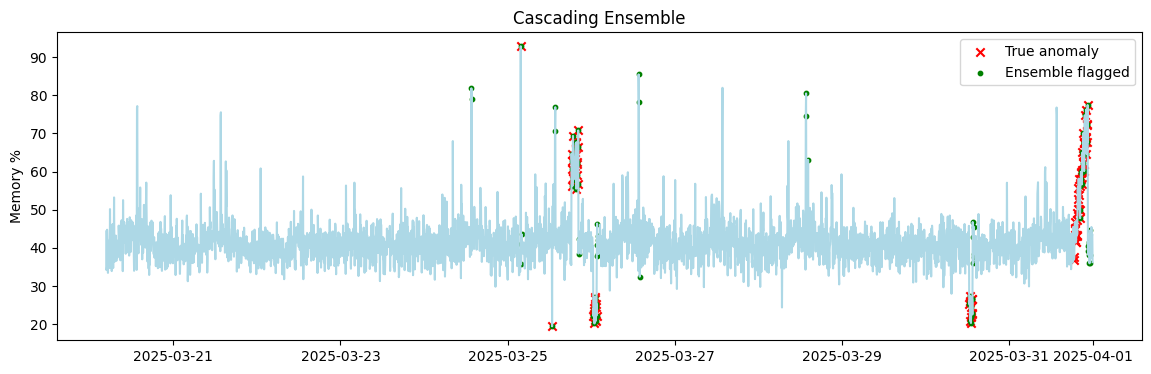

In [7]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

plt.figure(figsize=(14, 4))
plt.plot(timestamps, memory, color='lightblue')
plt.scatter(timestamps[y_test == 1], memory[y_test == 1], color='red', marker='x', label='True anomaly')
plt.scatter(timestamps[final_predictions == 1], memory[final_predictions == 1], color='green', s=10, label='Ensemble flagged')
plt.title('Cascading Ensemble')
plt.ylabel('Memory %')
plt.legend()
plt.show()

## Evaluation

In [8]:
print(classification_report(y_test, final_predictions, target_names=['Normal','Anomaly'], zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, final_predictions))
print('ROC-AUC:', round(roc_auc_score(y_test, ensemble_score), 4))

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      3301
     Anomaly       0.68      0.81      0.73        98

    accuracy                           0.98      3399
   macro avg       0.83      0.90      0.86      3399
weighted avg       0.99      0.98      0.98      3399

Confusion matrix:
[[3263   38]
 [  19   79]]
ROC-AUC: 0.9011


## Statistical analysis using statsmodels
Logistic regression to evaluate statistical significance of features.

In [ ]:
X_with_constant = sm.add_constant(train_data[new_features].values)
logit_model = sm.Logit(train_data['label'].values, X_with_constant)
logit_result = logit_model.fit()
print(logit_result.summary())

In [ ]:
print('Pseudo R-squared:', round(logit_result.prsquared, 4))
print('LLR p-value:', logit_result.llr_pvalue)
print('AIC:', round(logit_result.aic, 2))
print('BIC:', round(logit_result.bic, 2))